# Ride Trip Data - Linear Regression
### Predicting Ride Duration using Linear Regression

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import Lasso, Ridge, ElasticNet
import warnings
warnings.filterwarnings('ignore')

### Load Dataset & Feature Engineering

In [42]:
df = pd.read_csv(r"C:\Users\Nishant\Downloads\divvy_trip_data_202312_filled.csv")

In [43]:
df['started_at']= pd.to_datetime(df['started_at'])
df['ended_at']= pd.to_datetime(df['ended_at'])

df['ride_duration']=(df['ended_at'] - df['started_at']).dt.total_seconds() / 60
df['started_hour']=df['started_at'].dt.hour
df['started_day']=df['started_at'].dt.dayofweek   # 0=Monday … 6=Sunday
df['started_month']=df['started_at'].dt.month
df['is_weekend']=(df['started_day'] >= 5).astype(int)

In [44]:
df.rename(columns={'ride_id':            'Ride_ID',
    'rideable_type':      'Rideable_Type',
    'started_at':         'Started_At',
    'ended_at':           'Ended_At',
    'start_station_name': 'Start_Station_Name',
    'start_station_id':   'Start_Station_ID',
    'end_station_name':   'End_Station_Name',
    'end_station_id':     'End_Station_ID',
    'start_lat':          'Start_Lat',
    'start_lng':          'Start_Lng',
    'end_lat':            'End_Lat',
    'end_lng':            'End_Lng',
    'member_casual':      'Member_Casual',
    'started_hour':       'Started_Hour',
    'started_day':        'Started_Day',
    'started_month':      'Started_Month',
    'is_weekend':         'Is_Weekend'}, inplace=True)

df.head()

,Ride_ID,Rideable_Type,Started_At,Ended_At,Start_Station_Name,Start_Station_ID,End_Station_Name,End_Station_ID,Start_Lat,Start_Lng,End_Lat,End_Lng,Member_Casual,ride_duration,Started_Hour,Started_Day,Started_Month,Is_Weekend
0,C9BD54F578F57246,electric_bike,2023-12-02 18:44:01,2023-12-02 18:47:51,Kingsbury St & Kinzie St,KA1503000043,Clinton St & Washington Blvd,WL-012,41.92,-87.66,41.92,-87.66,member,3.833333,18,5,12,1
1,CDBD92F067FA620E,electric_bike,2023-12-02 18:48:19,2023-12-02 18:54:48,Kingsbury St & Kinzie St,KA1503000043,Clinton St & Washington Blvd,WL-012,41.92,-87.66,41.89,-87.64,member,6.483333,18,5,12,1
2,ABC0858E52CBFC84,electric_bike,2023-12-24 01:56:32,2023-12-24 02:04:09,Kingsbury St & Kinzie St,KA1503000043,Clinton St & Washington Blvd,WL-012,41.89,-87.62,41.90,-87.64,member,7.616667,1,6,12,1
3,F44B6F0E8F76DC90,electric_bike,2023-12-24 10:58:12,2023-12-24 11:03:04,Kingsbury St & Kinzie St,KA1503000043,Clinton St & Washington Blvd,WL-012,41.95,-87.65,41.94,-87.65,member,4.866667,10,6,12,1
4,3C876413281A90DF,electric_bike,2023-12-24 12:43:16,2023-12-24 12:44:57,Kingsbury St & Kinzie St,KA1503000043,Clinton St & Washington Blvd,WL-012,41.92,-87.64,41.93,-87.64,member,1.683333,12,6,12,1


### Dataset Preprocessing

In [45]:
df.columns

Index(['Ride_ID', 'Rideable_Type', 'Started_At', 'Ended_At',
       'Start_Station_Name', 'Start_Station_ID', 'End_Station_Name',
       'End_Station_ID', 'Start_Lat', 'Start_Lng', 'End_Lat', 'End_Lng',
       'Member_Casual', 'ride_duration', 'Started_Hour', 'Started_Day',
       'Started_Month', 'Is_Weekend'],
      dtype='object')

In [46]:
df.describe()

,Started_At,Ended_At,Start_Lat,Start_Lng,End_Lat,End_Lng,ride_duration,Started_Hour,Started_Day,Started_Month,Is_Weekend
count,224073,224073,224073.000000,224073.000000,223834.000000,223834.000000,224073.000000,224073.000000,224073.000000,224073.0,224073.000000
mean,2023-12-14 08:30:56.735229184,2023-12-14 08:44:20.967921152,41.901721,-87.648399,41.901926,-87.648467,13.403878,13.542426,3.045360,12.0,0.262736
min,2023-12-01 00:00:03,2023-12-01 00:04:12,41.648501,-87.850000,41.648501,-87.960000,-14.650000,0.000000,0.000000,12.0,0.000000
25%,2023-12-07 16:18:35,2023-12-07 16:30:49,41.880330,-87.661364,41.880419,-87.661364,4.683333,10.000000,2.000000,12.0,0.000000
50%,2023-12-13 12:05:44,2023-12-13 12:16:31,41.896617,-87.644448,41.896617,-87.644448,7.700000,14.000000,3.000000,12.0,0.000000
75%,2023-12-20 14:14:23,2023-12-20 14:28:48,41.930000,-87.630876,41.930000,-87.630876,13.000000,17.000000,5.000000,12.0,1.000000
max,2023-12-31 23:59:38,2024-01-01 23:50:51,42.070000,-87.528232,42.070000,-87.528232,1499.950000,23.000000,6.000000,12.0,1.000000
std,NaN,NaN,0.044201,0.026874,0.044248,0.026941,57.993330,4.969455,1.880965,0.0,0.440121


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 224073 entries, 0 to 224072
Data columns (total 18 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   Ride_ID             224073 non-null  object        
 1   Rideable_Type       224073 non-null  object        
 2   Started_At          224073 non-null  datetime64[ns]
 3   Ended_At            224073 non-null  datetime64[ns]
 4   Start_Station_Name  224073 non-null  object        
 5   Start_Station_ID    224073 non-null  object        
 6   End_Station_Name    224073 non-null  object        
 7   End_Station_ID      224073 non-null  object        
 8   Start_Lat           224073 non-null  float64       
 9   Start_Lng           224073 non-null  float64       
 10  End_Lat             223834 non-null  float64       
 11  End_Lng             223834 non-null  float64       
 12  Member_Casual       224073 non-null  object        
 13  ride_duration       224073 no

In [21]:
df.isnull().sum()

Ride_ID                 0
Rideable_Type           0
Started_At              0
Ended_At                0
Start_Station_Name      0
Start_Station_ID        0
End_Station_Name        0
End_Station_ID          0
Start_Lat               0
Start_Lng               0
End_Lat               239
End_Lng               239
Member_Casual           0
ride_duration           0
Started_Hour            0
Started_Day             0
Started_Month           0
Is_Weekend              0
dtype: int64

In [22]:
f.dropna(subset=['End_Lat', 'End_Lng', 'End_Station_Name', 'End_Station_ID',
                  'Start_Station_Name', 'Start_Station_ID'], inplace=True)
df = df[df['ride_duration'] > 0]
df = df[df['ride_duration'] <= 1440]
print("Cleaned shape:", df.shape)

Cleaned shape: (223755, 18)


In [23]:
df.duplicated().sum()

np.int64(0)

### Exploratory Data Analysis (EDA)

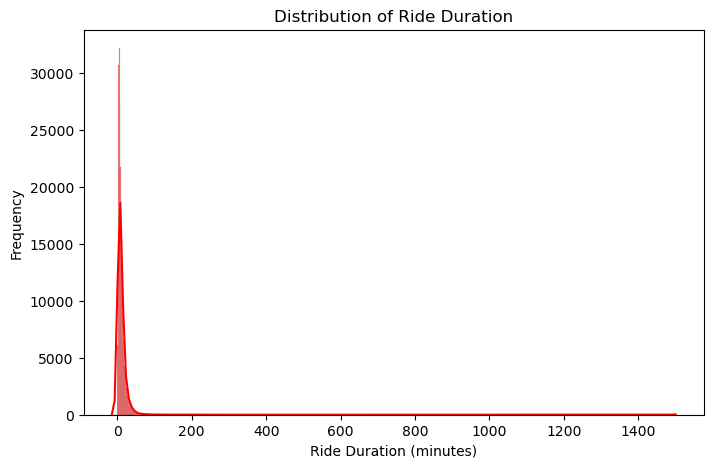

In [48]:
plt.figure(figsize=(8, 5))
sns.histplot(df['ride_duration'], color='Red', kde=True)
plt.title('Distribution of Ride Duration')
plt.xlabel('Ride Duration (minutes)')
plt.ylabel('Frequency')
plt.show()

### Inference: Most rides are short with a right-skewed distribution.

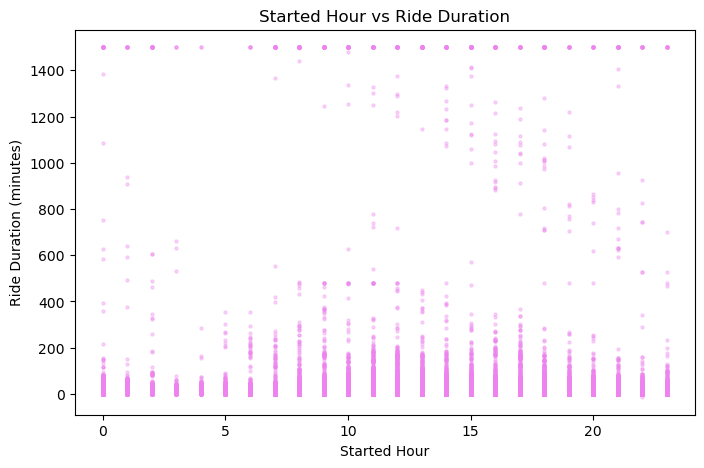

In [54]:
plt.figure(figsize=(8, 5))
plt.scatter(df['Started_Hour'], df['ride_duration'], alpha=0.3,color='Violet', s=5)
plt.xlabel('Started Hour')
plt.ylabel('Ride Duration (minutes)')
plt.title('Started Hour vs Ride Duration')
plt.show()

### Inference: Rides started during early morning and midday hours tend to be slightly longer.

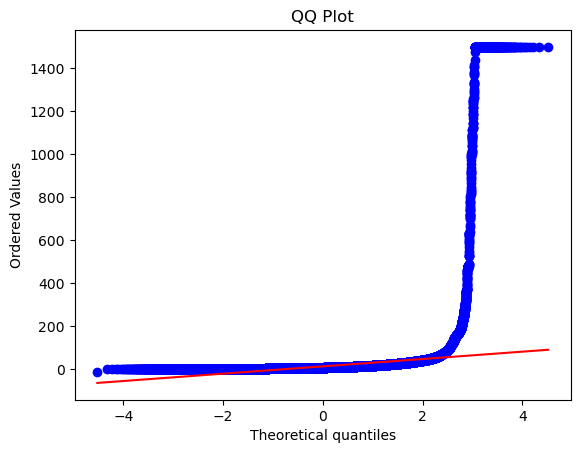

In [55]:
stats.probplot(df['ride_duration'], dist='norm', plot=plt)
plt.title('QQ Plot')
plt.show()

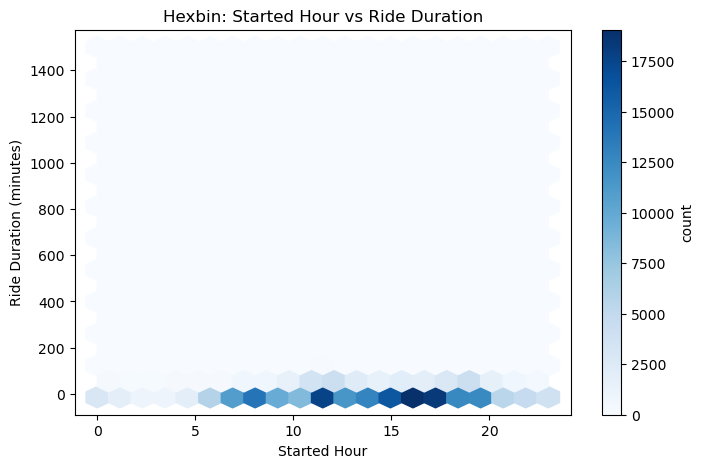

In [58]:
plt.figure(figsize=(8, 5))
plt.hexbin(df['Started_Hour'], df['ride_duration'], gridsize=20, cmap='Blues')
plt.colorbar(label='count')
plt.xlabel('Started Hour')
plt.ylabel('Ride Duration (minutes)')
plt.title('Hexbin: Started Hour vs Ride Duration')
plt.show()

### Inference: Dense clusters around commute hours (7–9 AM, 4–7 PM) show many short rides.

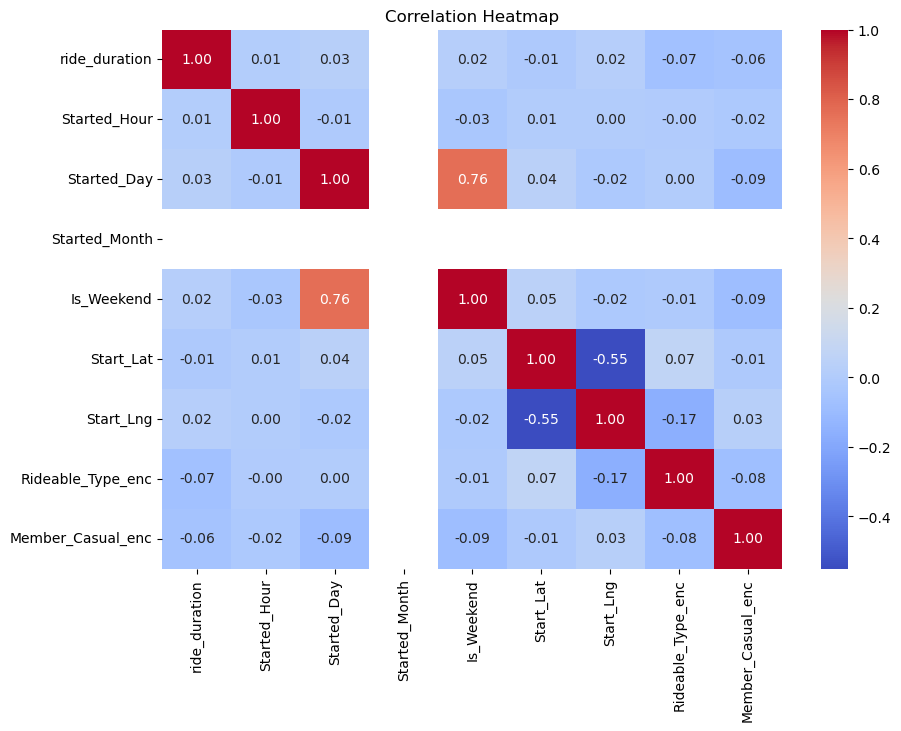

In [28]:
# Encode categorical for correlation
le = LabelEncoder()
df['Rideable_Type_enc'] = le.fit_transform(df['Rideable_Type'])
df['Member_Casual_enc'] = le.fit_transform(df['Member_Casual'])

num_cols = ['ride_duration', 'Started_Hour', 'Started_Day', 'Started_Month',
            'Is_Weekend', 'Start_Lat', 'Start_Lng', 'Rideable_Type_enc', 'Member_Casual_enc']

plt.figure(figsize=(10, 7))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

### Inference: Member type (casual vs member) has a notable relationship with ride duration — casual riders tend to ride longer.

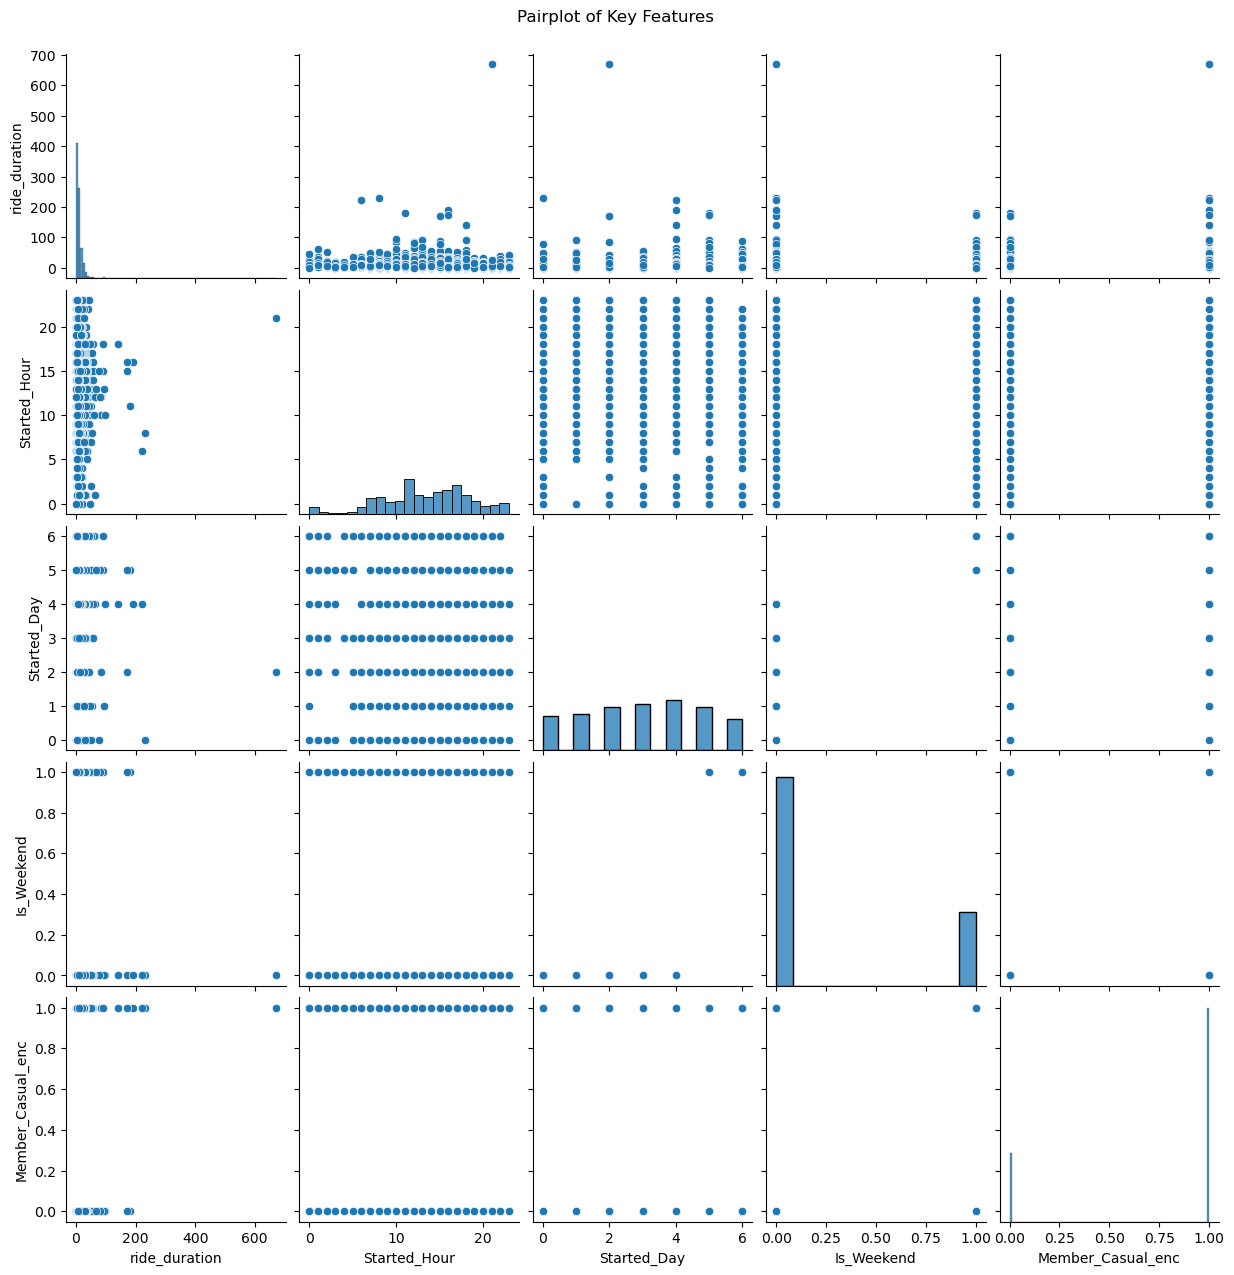

In [29]:
sns.pairplot(df[['ride_duration','Started_Hour','Started_Day','Is_Weekend','Member_Casual_enc']].sample(2000, random_state=42))
plt.suptitle('Pairplot of Key Features', y=1.02)
plt.show()

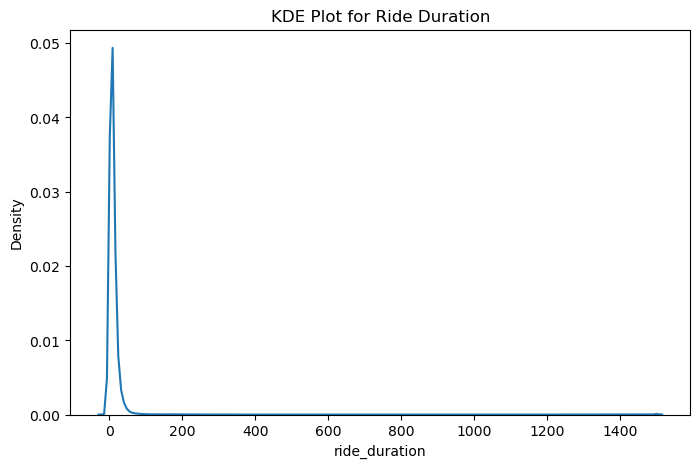

In [62]:
plt.figure(figsize=(8, 5))
sns.kdeplot(df['ride_duration'])
plt.title('KDE Plot for Ride Duration')
plt.show()

## Train Test Split

In [31]:
feature_cols = ['Started_Hour', 'Started_Day', 'Started_Month',
                'Is_Weekend', 'Start_Lat', 'Start_Lng',
                'Rideable_Type_enc', 'Member_Casual_enc']
x = df[feature_cols]
y = df['ride_duration']

In [32]:
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.80, random_state=42)
print('Training Shape:', x_train.shape)
print('Testing Shape: ', x_test.shape)

Training Shape: (179004, 8)
Testing Shape:  (44751, 8)


## Model Building - Linear Regression

In [33]:
lr = LinearRegression()

In [34]:
lr.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [35]:
y_pred=lr.predict(x_test)

## Model Evaluation

In [36]:
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)
print('MAE :     ', mae)
print('MSE :     ', mse)
print('RMSE:     ', rmse)
print('R2 Score:', r2)

MAE :      8.128863904414887
MSE :      874.8585997079084
RMSE:      29.57800871776037
R2 Score: 0.0070784749332695185


# Regularization Models

In [37]:
ridge   = Ridge()
lasso   = Lasso()
elastic = ElasticNet()

ridge.fit(x_train, y_train)
lasso.fit(x_train, y_train)
elastic.fit(x_train, y_train)

ridge_pred   = ridge.predict(x_test)
lasso_pred   = lasso.predict(x_test)
elastic_pred = elastic.predict(x_test)

In [61]:
models = {
    'Linear Regression': y_pred,
    'Ridge':             ridge_pred,
    'Lasso':             lasso_pred,
    'ElasticNet':        elastic_pred}
results = []
for name, prediction in models.items():
    results.append({
        'Model':    name,
        'R2 Score': r2_score(y_test, prediction),
        'MAE':      mean_absolute_error(y_test, prediction)})
results_df = pd.DataFrame(results)
results_df

,Model,R2 Score,MAE
0,Linear Regression,0.007078,8.128864
1,Ridge,0.007078,8.128651
2,Lasso,0.000246,8.094409
3,ElasticNet,0.002023,8.061563


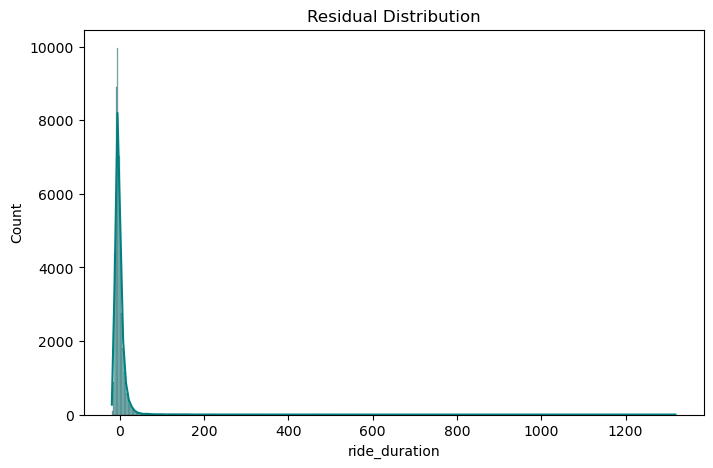

In [60]:
residuals = y_test - y_pred
plt.figure(figsize=(8, 5))
sns.histplot(residuals,color="Teal" ,kde=True)
plt.title('Residual Distribution')
plt.show()

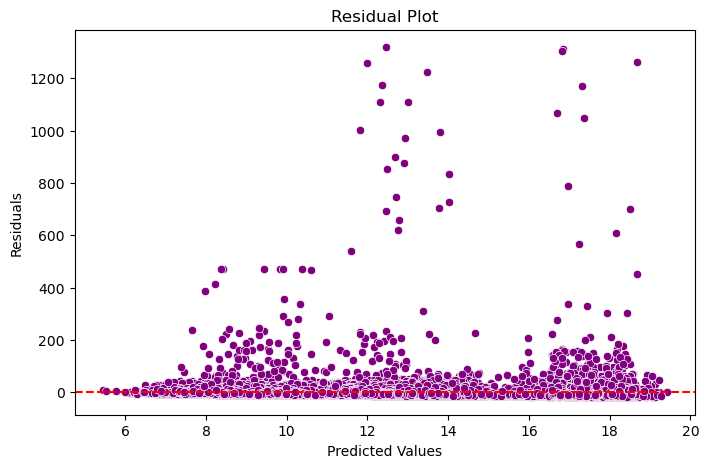

In [59]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred, y=residuals, color="Purple")
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

In [29]:
split_sizes = [0.6, 0.7, 0.8, 0.9]
r2_scores   = []
for size in split_sizes:
    x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=size, random_state=42)
    scaler = StandardScaler()
    x_train_scaled = scaler.fit_transform(x_train)
    x_test_scaled  = scaler.transform(x_test)
    lr = LinearRegression()
    lr.fit(x_train_scaled, y_train)
    y_pred = lr.predict(x_test_scaled)
    r2 = r2_score(y_test, y_pred)
    r2_scores.append(r2)
    print(f'Train Size: {int(size * 100)}%')
    print(f'R2 Score:   {r2}\n')

Train Size: 60%
R2 Score:   0.008387843745267798

Train Size: 70%
R2 Score:   0.0073723717242476505

Train Size: 80%
R2 Score:   0.0070784749332695185

Train Size: 90%
R2 Score:   0.010074054011293354

